# Comprehensive Statistical Evaluation of SC-OTS Experimental Results

This notebook performs a comprehensive statistical evaluation of Simplicial-Constrained Oblique Tree Sums (SC-OTS) across 3 experiment dependencies. It computes 7 metrics:

1. **Pairwise Wilcoxon tests** with Holm-Bonferroni correction (36 pairs tested)
2. **Friedman + Nemenyi CD diagram** (9 methods)
3. **Error analysis** with Spearman correlations
4. **XGBoost+SC benefit** (Cohen's d per dataset)
5. **Interaction recovery curves** on 4 synthetic datasets
6. **Pareto frontier** (complexity vs accuracy rank)
7. **OLS regression** of dataset characteristics

The evaluation loads pre-computed per-fold scores from 10 datasets × 11 methods and produces statistical comparisons, hypothesis testing, and visualizations.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# scikit-posthocs — NOT on Colab, always install
_pip('scikit-posthocs==0.11.2')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1',
         'scipy==1.16.3', 'matplotlib==3.10.0', 'statsmodels==0.14.6',
         'tabulate==0.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import io
import base64
import warnings

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import wilcoxon, friedmanchisquare, spearmanr, rankdata
from statsmodels.stats.multitest import multipletests
import scikit_posthocs as sp
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tabulate import tabulate

warnings.filterwarnings("ignore")
%matplotlib inline

## Data Loading

Load pre-computed per-fold scores and experiment metadata from `mini_demo_data.json`. This file contains:
- **fold_scores**: 480 per-fold scores (10 datasets × 11 methods × ~5 folds)
- **exp1_meta**: Dataset characteristics (n_features, n_samples, task_type, etc.)
- **exp3_meta**: Interaction recovery data from TDA validation

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-f5f9f2-simplicial-constrained-oblique-tree-sums/main/evaluation_iter3_comprehensive_s/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data keys: {list(data.keys())}")
print(f"  fold_scores: {len(data['fold_scores'])} entries")
print(f"  exp1_meta datasets: {list(data['exp1_meta']['per_dataset_results'].keys())}")
print(f"  exp3_meta keys: {list(data['exp3_meta'].keys())}")

Loaded data keys: ['fold_scores', 'exp1_meta', 'exp3_meta']
  fold_scores: 480 entries
  exp1_meta datasets: ['friedman1', 'friedman3', 'synth_3way', 'synth_4way', 'diabetes', 'breast_w', 'wine_quality', 'california_housing', 'spambase', 'adult']
  exp3_meta keys: ['enhanced_interaction_dcor', 'step4_interaction_recovery', 'baseline_pearson']


## Configuration

Constants and method definitions used throughout the evaluation.

In [5]:
# ── Configuration ────────────────────────────────────────────────────
DATASET_ORDER = [
    "friedman1", "friedman3", "synth_3way", "synth_4way",
    "diabetes", "breast_w", "wine_quality", "california_housing",
    "spambase", "adult",
]
SYNTHETIC_DATASETS = ["friedman1", "friedman3", "synth_3way", "synth_4way"]

# Complexity assignments (total splits proxy)
COMPLEXITY_MAP = {
    "SC-OTS": 20, "RO-FIGS": 20,
    "FIGS-5": 5, "FIGS-10": 10, "FIGS-20": 20,
    "XGBoost": 600, "XGBoost-oracle": 600, "XGBoost+SC": 600,
    "EBM": 500, "EBM-high": 500, "EBM-3way": 500,
}

# Methods from exp_id1 (shared folds with SC-OTS)
EXP1_METHODS = ["SC-OTS", "RO-FIGS", "FIGS-20", "XGBoost", "XGBoost+SC", "EBM"]
# Additional methods only in exp_id2
EXP2_ONLY_METHODS = ["FIGS-5", "FIGS-10", "XGBoost-oracle", "EBM-high", "EBM-3way"]
ALL_METHODS = EXP1_METHODS + EXP2_ONLY_METHODS

# Figure DPI
FIGURE_DPI = 100

## Helper Functions

Utility functions for figure encoding and metric computation.

In [6]:
def fig_to_base64(fig: plt.Figure, dpi: int = FIGURE_DPI) -> str:
    """Convert matplotlib figure to base64 PNG string."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return b64


def compute_r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Compute R-squared."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 0.0
    return float(1.0 - ss_res / ss_tot)


def compute_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Compute accuracy for classification."""
    return float(np.mean(y_true == np.round(y_pred)))

## Build Unified DataFrame

Construct the unified per-fold score DataFrame and compute per-dataset mean scores across folds.

In [7]:
# Build fold_df from pre-computed fold scores
fold_df = pd.DataFrame(data["fold_scores"])
exp1_meta = data["exp1_meta"]
exp3_meta = data["exp3_meta"]

print(f"Unified DataFrame: {len(fold_df)} rows")
print(f"  Methods: {sorted(fold_df['method'].unique())}")
print(f"  Datasets: {sorted(fold_df['dataset'].unique())}")

# Compute mean scores per (dataset, method)
def compute_mean_scores(df: pd.DataFrame) -> pd.DataFrame:
    """Pivot: (dataset, method) -> mean score across folds."""
    pivot = df.groupby(["dataset", "method"])["score"].mean().reset_index()
    pivot_wide = pivot.pivot(index="dataset", columns="method", values="score")
    ordered_ds = [d for d in DATASET_ORDER if d in pivot_wide.index]
    pivot_wide = pivot_wide.loc[ordered_ds]
    return pivot_wide

mean_scores = compute_mean_scores(fold_df)
print(f"\nMean score matrix: {mean_scores.shape}")
print(mean_scores.round(4).to_string())

Unified DataFrame: 480 rows
  Methods: ['EBM', 'EBM-3way', 'EBM-high', 'FIGS-10', 'FIGS-20', 'FIGS-5', 'RO-FIGS', 'SC-OTS', 'XGBoost', 'XGBoost+SC', 'XGBoost-oracle']
  Datasets: ['adult', 'breast_w', 'california_housing', 'diabetes', 'friedman1', 'friedman3', 'spambase', 'synth_3way', 'synth_4way', 'wine_quality']

Mean score matrix: (10, 11)
method                 EBM  EBM-3way  EBM-high  FIGS-10  FIGS-20  FIGS-5  RO-FIGS  SC-OTS  XGBoost  XGBoost+SC  XGBoost-oracle
dataset                                                                                                                       
friedman1           0.9983       NaN    0.9968   0.8212   0.9146  0.6870   0.7328  0.7430   0.9735      0.9876          0.9935
friedman3           0.8842       NaN    0.8727   0.7663   0.8284  0.6837   0.7090  0.7095   0.8742      0.8763          0.8742
synth_3way          0.9857    0.9373    0.9837   0.7904   0.8762  0.6647   0.6869  0.6893   0.9696      0.9383          0.9826
synth_4way         

## Metric 1: Pairwise Wilcoxon Signed-Rank Tests

Test all method pairs using Wilcoxon signed-rank tests with Holm-Bonferroni correction for multiple comparisons.

In [8]:
def metric1_wilcoxon_pairwise(mean_scores: pd.DataFrame) -> dict:
    """Pairwise Wilcoxon signed-rank tests with Holm-Bonferroni correction."""
    methods = [m for m in ALL_METHODS if m in mean_scores.columns]
    n_methods = len(methods)
    n_datasets = len(mean_scores)

    pairs = []
    raw_pvals = []
    pair_stats = []

    for i in range(n_methods):
        for j in range(i + 1, n_methods):
            ma, mb = methods[i], methods[j]
            common_idx = mean_scores[[ma, mb]].dropna().index
            if len(common_idx) < 5:
                continue

            sa = mean_scores.loc[common_idx, ma].values
            sb = mean_scores.loc[common_idx, mb].values
            diff = sa - sb

            if np.all(diff == 0):
                pairs.append((ma, mb))
                raw_pvals.append(1.0)
                pair_stats.append({
                    "method_a": ma, "method_b": mb,
                    "raw_p_value": 1.0, "mean_difference": 0.0,
                    "method_a_wins": 0, "method_b_wins": 0,
                    "n_common_datasets": int(len(common_idx)),
                })
                continue

            try:
                stat, p = wilcoxon(sa, sb, alternative="two-sided", zero_method="pratt")
            except ValueError:
                p = 1.0

            pairs.append((ma, mb))
            raw_pvals.append(p)
            pair_stats.append({
                "method_a": ma, "method_b": mb,
                "raw_p_value": float(p),
                "mean_difference": float(np.mean(diff)),
                "method_a_wins": int(np.sum(diff > 0)),
                "method_b_wins": int(np.sum(diff < 0)),
                "n_common_datasets": int(len(common_idx)),
            })

    # Holm-Bonferroni correction
    if raw_pvals:
        reject, corrected, _, _ = multipletests(raw_pvals, method="holm")
        for k, ps in enumerate(pair_stats):
            ps["corrected_p_value"] = float(corrected[k])
            ps["significant_at_005"] = bool(corrected[k] < 0.05)
            ps["significant_at_010"] = bool(corrected[k] < 0.10)

    # SC-OTS comparisons summary
    scots_worse, scots_better, scots_not_sig = [], [], []
    for ps in pair_stats:
        if ps["method_a"] == "SC-OTS":
            other = ps["method_b"]
            if ps.get("significant_at_005", False):
                if ps["mean_difference"] > 0: scots_better.append(other)
                else: scots_worse.append(other)
            else: scots_not_sig.append(other)
        elif ps["method_b"] == "SC-OTS":
            other = ps["method_a"]
            if ps.get("significant_at_005", False):
                if ps["mean_difference"] < 0: scots_better.append(other)
                else: scots_worse.append(other)
            else: scots_not_sig.append(other)

    scots_rofigs_p = 1.0
    for ps in pair_stats:
        if (ps["method_a"] == "SC-OTS" and ps["method_b"] == "RO-FIGS") or \
           (ps["method_a"] == "RO-FIGS" and ps["method_b"] == "SC-OTS"):
            scots_rofigs_p = ps.get("corrected_p_value", 1.0)

    result = {
        "pair_tests": pair_stats,
        "total_pairs_tested": len(pairs),
        "total_significant_005": sum(1 for ps in pair_stats if ps.get("significant_at_005", False)),
        "total_significant_010": sum(1 for ps in pair_stats if ps.get("significant_at_010", False)),
        "sc_ots_significantly_worse_than": scots_worse,
        "sc_ots_significantly_better_than": scots_better,
        "sc_ots_not_significantly_different_from": scots_not_sig,
        "sc_ots_vs_rofigs_corrected_p": float(scots_rofigs_p),
        "n_datasets_tested": n_datasets,
        "limitation": f"With only {n_datasets} paired observations, Wilcoxon may have low power.",
    }
    return result

wilcoxon_results = metric1_wilcoxon_pairwise(mean_scores)
print(f"Wilcoxon: {wilcoxon_results['total_pairs_tested']} pairs tested")
print(f"  Significant at 0.05: {wilcoxon_results['total_significant_005']}")
print(f"  Significant at 0.10: {wilcoxon_results['total_significant_010']}")
print(f"  SC-OTS vs RO-FIGS corrected p: {wilcoxon_results['sc_ots_vs_rofigs_corrected_p']:.4f}")
print(f"  SC-OTS significantly better than: {wilcoxon_results['sc_ots_significantly_better_than']}")
print(f"  SC-OTS significantly worse than: {wilcoxon_results['sc_ots_significantly_worse_than']}")

Wilcoxon: 36 pairs tested
  Significant at 0.05: 0
  Significant at 0.10: 17
  SC-OTS vs RO-FIGS corrected p: 1.0000
  SC-OTS significantly better than: []
  SC-OTS significantly worse than: []


## Metric 2: Friedman Test + Nemenyi Post-Hoc with CD Diagram

Non-parametric Friedman test across all methods, followed by Nemenyi post-hoc comparison and critical difference diagram.

In [9]:
def metric2_friedman_nemenyi(mean_scores: pd.DataFrame) -> dict:
    """Friedman test + Nemenyi post-hoc with CD diagram."""
    # Only include methods with scores on all datasets
    valid_methods = []
    for m in ALL_METHODS:
        if m in mean_scores.columns and mean_scores[m].notna().all():
            valid_methods.append(m)

    if len(valid_methods) < 3:
        return {"error": "Insufficient methods"}

    score_matrix = mean_scores[valid_methods].values
    rank_matrix = np.zeros_like(score_matrix)
    for i in range(score_matrix.shape[0]):
        rank_matrix[i] = rankdata(-score_matrix[i])

    avg_ranks = {m: float(rank_matrix[:, j].mean()) for j, m in enumerate(valid_methods)}

    try:
        fstat, fp = friedmanchisquare(*[score_matrix[:, j] for j in range(len(valid_methods))])
    except Exception:
        fstat, fp = 0.0, 1.0

    # Nemenyi post-hoc
    nemenyi_pvals = {}
    cd_diagram_b64 = ""
    try:
        nemenyi_result = sp.posthoc_nemenyi_friedman(score_matrix)
        nemenyi_result.index = valid_methods
        nemenyi_result.columns = valid_methods
        nemenyi_pvals = nemenyi_result.to_dict()

        avg_ranks_series = pd.Series(avg_ranks)
        fig, ax = plt.subplots(figsize=(12, 4))
        try:
            sp.critical_difference_diagram(
                avg_ranks_series, nemenyi_result, ax=ax,
                label_fmt_left="{label} ({rank:.2f})",
                label_fmt_right="{label} ({rank:.2f})",
            )
            ax.set_title("Critical Difference Diagram (Nemenyi)", fontsize=14)
            cd_diagram_b64 = fig_to_base64(fig)
        except Exception:
            plt.close(fig)
            # Fallback: bar chart of average ranks
            fig2, ax2 = plt.subplots(figsize=(10, 5))
            sorted_ranks = sorted(avg_ranks.items(), key=lambda x: x[1])
            names = [x[0] for x in sorted_ranks]
            vals = [x[1] for x in sorted_ranks]
            colors = ["#2ecc71" if n == "SC-OTS" else "#3498db" for n in names]
            ax2.barh(names, vals, color=colors)
            ax2.set_xlabel("Average Rank (lower is better)")
            ax2.set_title("Method Rankings (Friedman/Nemenyi)")
            ax2.invert_yaxis()
            for i, v in enumerate(vals):
                ax2.text(v + 0.1, i, f"{v:.2f}", va="center")
            cd_diagram_b64 = fig_to_base64(fig2)
    except Exception:
        pass

    result = {
        "friedman_statistic": float(fstat),
        "friedman_p_value": float(fp),
        "friedman_significant": bool(fp < 0.05),
        "method_avg_ranks": avg_ranks,
        "nemenyi_p_value_matrix": nemenyi_pvals,
        "n_methods": len(valid_methods),
        "methods_tested": valid_methods,
        "cd_diagram_base64_png": cd_diagram_b64,
    }
    return result

friedman_results = metric2_friedman_nemenyi(mean_scores)
print(f"Friedman chi²={friedman_results['friedman_statistic']:.4f}, "
      f"p={friedman_results['friedman_p_value']:.2e}")
print(f"Significant: {friedman_results['friedman_significant']}")
print(f"Method average ranks:")
for m, r in sorted(friedman_results['method_avg_ranks'].items(), key=lambda x: x[1]):
    marker = " ◄" if m == "SC-OTS" else ""
    print(f"  {m:20s}: {r:.1f}{marker}")

Friedman chi²=60.8800, p=3.13e-10
Significant: True
Method average ranks:
  EBM                 : 1.7
  EBM-high            : 2.3
  XGBoost             : 3.0
  XGBoost+SC          : 3.7
  FIGS-20             : 5.3
  FIGS-10             : 6.4
  SC-OTS              : 7.2 ◄
  RO-FIGS             : 7.3
  FIGS-5              : 8.1


## Metric 3: Error Analysis

Per-dataset error analysis examining where SC-OTS underperforms and computing Spearman correlations between dataset characteristics and the performance gap.

In [10]:
def metric3_error_analysis(mean_scores: pd.DataFrame, exp1_meta: dict) -> dict:
    """Per-dataset error analysis: where and why SC-OTS underperforms."""
    per_ds_results = exp1_meta.get("per_dataset_results", {})
    rows = []

    for ds_name in DATASET_ORDER:
        if ds_name not in mean_scores.index:
            continue
        ds_meta = per_ds_results.get(ds_name, {})
        scots_score = mean_scores.loc[ds_name, "SC-OTS"] if "SC-OTS" in mean_scores.columns else np.nan

        baselines = [m for m in mean_scores.columns if m != "SC-OTS"]
        baseline_scores = mean_scores.loc[ds_name, baselines].dropna()
        if len(baseline_scores) == 0:
            continue

        best_baseline_score = baseline_scores.max()
        best_baseline_name = baseline_scores.idxmax()
        gap = float(scots_score - best_baseline_score)

        n_features = ds_meta.get("n_features", 0)
        n_samples = ds_meta.get("n_samples", 0)
        task_type = ds_meta.get("task_type", "unknown")
        n_simplices_dim1 = ds_meta.get("avg_n_simplices_dim1", 0)
        avg_threshold = ds_meta.get("avg_threshold", 0)
        avg_betti = ds_meta.get("avg_betti", [0, 0, 0])
        simplex_ratio = n_simplices_dim1 / n_features if n_features > 0 else 0

        rows.append({
            "dataset": ds_name,
            "sc_ots_score": float(scots_score),
            "best_baseline_score": float(best_baseline_score),
            "best_baseline_name": best_baseline_name,
            "gap": gap,
            "relative_gap_pct": float(gap / abs(best_baseline_score) * 100) if best_baseline_score != 0 else 0,
            "n_features": n_features,
            "n_samples": n_samples,
            "task_type": task_type,
            "category": ds_meta.get("category", "unknown"),
            "simplex_ratio": simplex_ratio,
            "avg_threshold": avg_threshold,
            "avg_betti_0": avg_betti[0] if len(avg_betti) > 0 else 0,
        })

    df_error = pd.DataFrame(rows)

    # Spearman correlations
    correlations = {}
    for char in ["n_features", "n_samples", "simplex_ratio", "avg_threshold"]:
        if len(df_error) >= 5:
            try:
                rho, p = spearmanr(df_error["gap"].values, df_error[char].values)
                correlations[f"gap_vs_{char}"] = {"spearman_rho": float(rho), "p_value": float(p)}
            except Exception:
                pass

    best_predictor = "none"
    best_abs_rho = 0
    for k, v in correlations.items():
        if abs(v["spearman_rho"]) > best_abs_rho:
            best_abs_rho = abs(v["spearman_rho"])
            best_predictor = k

    # Generate 2x2 scatter plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    chars = ["n_features", "n_samples", "simplex_ratio", "avg_threshold"]
    char_labels = ["Number of Features", "Number of Samples", "Simplex Ratio (dim1/features)", "Avg Threshold"]

    for idx, (char, label) in enumerate(zip(chars, char_labels)):
        ax = axes[idx // 2][idx % 2]
        x = df_error[char].values
        y = df_error["gap"].values
        ax.scatter(x, y, c="#e74c3c", s=80, zorder=5)
        ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
        for _, row in df_error.iterrows():
            ax.annotate(row["dataset"][:8], (row[char], row["gap"]),
                        fontsize=7, ha="center", va="bottom")
        ax.set_xlabel(label, fontsize=10)
        ax.set_ylabel("Gap (SC-OTS - Best Baseline)", fontsize=10)
        corr_info = correlations.get(f"gap_vs_{char}", {})
        rho_str = f"rho={corr_info.get('spearman_rho', 0):.3f}"
        ax.set_title(f"{label}\n{rho_str}", fontsize=11)

    fig.suptitle("Error Analysis: SC-OTS Performance Gap vs Dataset Characteristics", fontsize=13)
    fig.tight_layout()
    scatter_b64 = fig_to_base64(fig)

    result = {
        "per_dataset": rows,
        "spearman_correlations": correlations,
        "best_predictor_of_gap": best_predictor,
        "error_analysis_scatter_base64_png": scatter_b64,
    }
    return result

error_results = metric3_error_analysis(mean_scores, exp1_meta)
print(f"Error analysis: {len(error_results['per_dataset'])} datasets")
print(f"Best predictor of gap: {error_results['best_predictor_of_gap']}")
print(f"Spearman correlations:")
for k, v in error_results['spearman_correlations'].items():
    print(f"  {k}: rho={v['spearman_rho']:.3f}, p={v['p_value']:.3f}")

Error analysis: 10 datasets
Best predictor of gap: gap_vs_n_samples
Spearman correlations:
  gap_vs_n_features: rho=-0.073, p=0.841
  gap_vs_n_samples: rho=-0.488, p=0.153
  gap_vs_simplex_ratio: rho=0.406, p=0.244
  gap_vs_avg_threshold: rho=-0.212, p=0.556


## Metric 4: XGBoost+SC Benefit Analysis

Paired comparison of XGBoost vs XGBoost+SC using Cohen's d effect size per dataset.

In [11]:
def metric4_xgb_sc_benefit(fold_df: pd.DataFrame) -> dict:
    """Paired analysis of XGBoost vs XGBoost+SC benefit."""
    per_ds = []
    for ds_name in DATASET_ORDER:
        xgb_df = fold_df[(fold_df["dataset"] == ds_name) & (fold_df["method"] == "XGBoost")]
        xgb_sc_df = fold_df[(fold_df["dataset"] == ds_name) & (fold_df["method"] == "XGBoost+SC")]

        if len(xgb_df) == 0 or len(xgb_sc_df) == 0:
            continue

        merged = xgb_df.merge(xgb_sc_df, on=["dataset", "fold"], suffixes=("_xgb", "_xgb_sc"))
        if len(merged) == 0:
            continue

        xgb_vals = merged["score_xgb"].values
        xgb_sc_vals = merged["score_xgb_sc"].values

        mean_diff = float(np.mean(xgb_sc_vals - xgb_vals))
        std_xgb = float(np.std(xgb_vals, ddof=1)) if len(xgb_vals) > 1 else 0
        std_xgb_sc = float(np.std(xgb_sc_vals, ddof=1)) if len(xgb_sc_vals) > 1 else 0
        pooled_std = np.sqrt((std_xgb**2 + std_xgb_sc**2) / 2)
        cohens_d = float(mean_diff / pooled_std) if pooled_std > 0 else 0.0

        abs_d = abs(cohens_d)
        interp = "negligible" if abs_d < 0.2 else ("small" if abs_d < 0.5 else ("medium" if abs_d < 0.8 else "large"))

        wilcoxon_p = 1.0
        if len(merged) >= 5:
            diff = xgb_sc_vals - xgb_vals
            if not np.all(diff == 0):
                try:
                    _, wilcoxon_p = wilcoxon(xgb_sc_vals, xgb_vals, alternative="two-sided", zero_method="pratt")
                except ValueError:
                    pass

        per_ds.append({
            "dataset": ds_name,
            "xgb_mean": float(np.mean(xgb_vals)),
            "xgb_sc_mean": float(np.mean(xgb_sc_vals)),
            "mean_diff": mean_diff,
            "cohens_d": cohens_d,
            "cohens_d_interpretation": interp,
            "wilcoxon_p": float(wilcoxon_p),
            "xgb_sc_wins_folds": int(np.sum(xgb_sc_vals > xgb_vals)),
            "n_folds": int(len(merged)),
        })

    n_better = sum(1 for d in per_ds if d["mean_diff"] > 0)
    n_worse = sum(1 for d in per_ds if d["mean_diff"] < 0)
    mean_cd = float(np.mean([d["cohens_d"] for d in per_ds])) if per_ds else 0

    ds_means_xgb = np.array([d["xgb_mean"] for d in per_ds])
    ds_means_xgb_sc = np.array([d["xgb_sc_mean"] for d in per_ds])
    overall_wilcoxon_p = 1.0
    if len(ds_means_xgb) >= 5:
        diff = ds_means_xgb_sc - ds_means_xgb
        if not np.all(diff == 0):
            try:
                _, overall_wilcoxon_p = wilcoxon(ds_means_xgb_sc, ds_means_xgb, zero_method="pratt")
            except ValueError:
                pass

    overall_diff = ds_means_xgb_sc - ds_means_xgb
    overall_pooled = np.sqrt((np.var(ds_means_xgb, ddof=1) + np.var(ds_means_xgb_sc, ddof=1)) / 2)
    overall_cohens_d = float(np.mean(overall_diff) / overall_pooled) if overall_pooled > 0 else 0

    # Bar chart of Cohen's d per dataset
    fig, ax = plt.subplots(figsize=(10, 6))
    ds_names = [d["dataset"] for d in per_ds]
    ds_cd = [d["cohens_d"] for d in per_ds]
    colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in ds_cd]
    bars = ax.barh(ds_names, ds_cd, color=colors)
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.axvline(x=0.2, color="gray", linestyle="--", alpha=0.5, label="|d|=0.2 small")
    ax.axvline(x=-0.2, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(x=0.5, color="gray", linestyle=":", alpha=0.5, label="|d|=0.5 medium")
    ax.axvline(x=-0.5, color="gray", linestyle=":", alpha=0.5)
    ax.set_xlabel("Cohen's d (positive = XGBoost+SC better)")
    ax.set_title("XGBoost+SC Benefit: Cohen's d per Dataset")
    ax.legend(loc="lower right", fontsize=8)
    for i, (d, interp) in enumerate(zip(ds_cd, [p["cohens_d_interpretation"] for p in per_ds])):
        ax.text(d + 0.02 if d >= 0 else d - 0.02, i, interp, va="center",
                ha="left" if d >= 0 else "right", fontsize=8)
    fig.tight_layout()
    bar_b64 = fig_to_base64(fig)

    result = {
        "per_dataset": per_ds,
        "n_datasets_xgb_sc_better": n_better,
        "n_datasets_xgb_sc_worse": n_worse,
        "mean_cohens_d": mean_cd,
        "overall_wilcoxon_p": float(overall_wilcoxon_p),
        "overall_cohens_d": overall_cohens_d,
        "xgb_sc_benefit_base64_png": bar_b64,
    }
    return result

xgb_sc_results = metric4_xgb_sc_benefit(fold_df)
print(f"XGBoost+SC benefit: {xgb_sc_results['n_datasets_xgb_sc_better']} better, "
      f"{xgb_sc_results['n_datasets_xgb_sc_worse']} worse")
print(f"Mean Cohen's d: {xgb_sc_results['mean_cohens_d']:.3f}")
print(f"Overall Wilcoxon p: {xgb_sc_results['overall_wilcoxon_p']:.4f}")

XGBoost+SC benefit: 3 better, 7 worse
Mean Cohen's d: -1.658
Overall Wilcoxon p: 0.1055


## Metric 5: Interaction Recovery Curves

Evaluates how well SC-OTS recovers known feature interactions on synthetic datasets using enhanced dCor F1 scores at various thresholds.

In [12]:
def metric5_interaction_recovery(exp3_meta: dict) -> dict:
    """Interaction recovery analysis on synthetic datasets."""
    enhanced = exp3_meta.get("enhanced_interaction_dcor", {})
    step4 = exp3_meta.get("step4_interaction_recovery", {})
    pearson = exp3_meta.get("baseline_pearson", {})

    per_ds = []
    curves_data = {}

    for ds_name in SYNTHETIC_DATASETS:
        enh = enhanced.get(ds_name, {})
        s4 = step4.get(ds_name, {})
        prs = pearson.get(ds_name, {})

        mbt = enh.get("metrics_by_threshold", {})
        thresholds = sorted([float(t) for t in mbt.keys()])

        f1_values = []
        for t in thresholds:
            matched = False
            for k, v in mbt.items():
                if abs(float(k) - t) < 1e-8:
                    f1_values.append(v["f1"])
                    matched = True
                    break
            if not matched:
                f1_values.append(0.0)

        auc = float(np.trapezoid(f1_values, thresholds)) if len(thresholds) >= 2 else 0.0

        oracle_f1 = enh.get("f1_at_optimal", 0.0)
        oracle_threshold = enh.get("optimal_threshold", 0.0)
        gap_f1 = enh.get("f1_at_gap", 0.0)
        gap_threshold = enh.get("gap_threshold", 0.0)
        f1_gap_ratio = float(gap_f1 / oracle_f1) if oracle_f1 > 0 else 0.0

        per_ds.append({
            "dataset": ds_name,
            "oracle_f1": float(oracle_f1),
            "oracle_threshold": float(oracle_threshold),
            "gap_f1": float(gap_f1),
            "gap_threshold": float(gap_threshold),
            "f1_gap_ratio": f1_gap_ratio,
            "auc_f1_threshold": auc,
            "pairwise_dcor_optimal_f1": float(s4.get("f1_at_optimal", 0)),
            "pairwise_dcor_gap_f1": float(s4.get("f1_at_gap", 0)),
            "pearson_optimal_f1": float(prs.get("f1_at_optimal", 0)),
            "pearson_gap_f1": float(prs.get("f1_at_gap", 0)),
        })

        curves_data[ds_name] = {
            "thresholds": thresholds, "f1_values": f1_values,
            "gap_threshold": gap_threshold, "oracle_threshold": oracle_threshold,
            "gap_f1": gap_f1, "oracle_f1": oracle_f1,
        }

    # 4-panel F1 vs threshold plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for idx, ds_name in enumerate(SYNTHETIC_DATASETS):
        ax = axes[idx // 2][idx % 2]
        cd = curves_data.get(ds_name, {})
        thresholds = cd.get("thresholds", [])
        f1_values = cd.get("f1_values", [])

        if thresholds and f1_values:
            ax.plot(thresholds, f1_values, "b-", linewidth=2, label="F1 vs threshold")
            gap_t = cd.get("gap_threshold", 0)
            oracle_t = cd.get("oracle_threshold", 0)
            ax.axvline(x=gap_t, color="red", linestyle="--", linewidth=1.5,
                      label=f"Gap ({gap_t:.3f}), F1={cd.get('gap_f1', 0):.3f}")
            ax.axvline(x=oracle_t, color="green", linestyle="-", linewidth=1.5,
                      label=f"Oracle ({oracle_t:.3f}), F1={cd.get('oracle_f1', 0):.3f}")

        ax.set_xlabel("Threshold", fontsize=10)
        ax.set_ylabel("F1 Score", fontsize=10)
        ax.set_title(f"{ds_name}", fontsize=12)
        ax.legend(fontsize=8, loc="best")
        ax.set_ylim(-0.05, 1.1)
        ax.grid(True, alpha=0.3)

    fig.suptitle("Interaction Recovery: Enhanced dCor F1 vs Threshold", fontsize=14)
    fig.tight_layout()
    curves_b64 = fig_to_base64(fig)

    # Comparison bar chart
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    x_pos = np.arange(len(SYNTHETIC_DATASETS))
    width = 0.25
    pw_dcor_f1 = [next((d["pairwise_dcor_optimal_f1"] for d in per_ds if d["dataset"] == ds), 0)
                  for ds in SYNTHETIC_DATASETS]
    enh_dcor_f1 = [next((d["oracle_f1"] for d in per_ds if d["dataset"] == ds), 0)
                   for ds in SYNTHETIC_DATASETS]
    pearson_f1 = [next((d["pearson_optimal_f1"] for d in per_ds if d["dataset"] == ds), 0)
                  for ds in SYNTHETIC_DATASETS]

    ax2.bar(x_pos - width, pw_dcor_f1, width, label="Pairwise dCor", color="#3498db")
    ax2.bar(x_pos, enh_dcor_f1, width, label="Enhanced dCor", color="#2ecc71")
    ax2.bar(x_pos + width, pearson_f1, width, label="Pearson", color="#e74c3c")
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(SYNTHETIC_DATASETS, rotation=15)
    ax2.set_ylabel("Optimal F1 Score")
    ax2.set_title("Interaction Recovery: Method Comparison (Optimal F1)")
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis="y")
    fig2.tight_layout()
    comparison_b64 = fig_to_base64(fig2)

    mean_oracle_f1 = float(np.mean([d["oracle_f1"] for d in per_ds])) if per_ds else 0
    mean_gap_f1 = float(np.mean([d["gap_f1"] for d in per_ds])) if per_ds else 0
    mean_f1_gap_ratio = float(np.mean([d["f1_gap_ratio"] for d in per_ds])) if per_ds else 0

    result = {
        "per_dataset": per_ds,
        "mean_oracle_f1": mean_oracle_f1,
        "mean_gap_f1": mean_gap_f1,
        "mean_f1_gap_ratio": mean_f1_gap_ratio,
        "pairwise_dcor_mean_f1": float(np.mean([d["pairwise_dcor_optimal_f1"] for d in per_ds])) if per_ds else 0,
        "enhanced_dcor_mean_f1": mean_oracle_f1,
        "pearson_mean_f1": float(np.mean([d["pearson_optimal_f1"] for d in per_ds])) if per_ds else 0,
        "interaction_recovery_curves_base64_png": curves_b64,
        "interaction_comparison_base64_png": comparison_b64,
    }
    return result

interaction_results = metric5_interaction_recovery(exp3_meta)
print(f"Interaction recovery:")
print(f"  Mean oracle F1: {interaction_results['mean_oracle_f1']:.3f}")
print(f"  Mean gap F1: {interaction_results['mean_gap_f1']:.3f}")
print(f"  Enhanced dCor mean F1: {interaction_results['enhanced_dcor_mean_f1']:.3f}")
print(f"  Pairwise dCor mean F1: {interaction_results['pairwise_dcor_mean_f1']:.3f}")
print(f"  Pearson mean F1: {interaction_results['pearson_mean_f1']:.3f}")

Interaction recovery:
  Mean oracle F1: 0.748
  Mean gap F1: 0.356
  Enhanced dCor mean F1: 0.748
  Pairwise dCor mean F1: 0.306
  Pearson mean F1: 0.317


## Metric 6: Pareto Frontier

Complexity-accuracy Pareto frontier analysis: identifies methods that are not dominated in terms of both model complexity and average rank.

In [13]:
def metric6_pareto_frontier(mean_scores: pd.DataFrame) -> dict:
    """Complexity-accuracy Pareto frontier analysis."""
    n_datasets = len(mean_scores)
    methods = [m for m in ALL_METHODS if m in mean_scores.columns]
    score_mat = mean_scores[methods].values
    rank_mat = np.zeros_like(score_mat)
    for i in range(score_mat.shape[0]):
        valid = ~np.isnan(score_mat[i])
        if valid.any():
            rank_mat[i, valid] = rankdata(-score_mat[i, valid])
            rank_mat[i, ~valid] = np.nan

    avg_ranks = {}
    for j, m in enumerate(methods):
        avg_ranks[m] = float(np.nanmean(rank_mat[:, j]))

    points = []
    for m in methods:
        c = COMPLEXITY_MAP.get(m, 100)
        r = avg_ranks[m]
        points.append({"method": m, "complexity": c, "avg_rank": r})

    points.sort(key=lambda x: (x["complexity"], x["avg_rank"]))

    # Find Pareto-optimal (non-dominated) points
    pareto_optimal = []
    for p in points:
        dominated = False
        for q in points:
            if q["method"] == p["method"]:
                continue
            if q["complexity"] <= p["complexity"] and q["avg_rank"] <= p["avg_rank"]:
                if q["complexity"] < p["complexity"] or q["avg_rank"] < p["avg_rank"]:
                    dominated = True
                    break
        if not dominated:
            pareto_optimal.append(p["method"])

    scots_point = next((p for p in points if p["method"] == "SC-OTS"), None)
    scots_dominated_by, scots_dominates = [], []
    if scots_point:
        for p in points:
            if p["method"] == "SC-OTS":
                continue
            if p["complexity"] <= scots_point["complexity"] and p["avg_rank"] <= scots_point["avg_rank"]:
                if p["complexity"] < scots_point["complexity"] or p["avg_rank"] < scots_point["avg_rank"]:
                    scots_dominated_by.append(p["method"])
            if scots_point["complexity"] <= p["complexity"] and scots_point["avg_rank"] <= p["avg_rank"]:
                if scots_point["complexity"] < p["complexity"] or scots_point["avg_rank"] < p["avg_rank"]:
                    scots_dominates.append(p["method"])

    # Generate Pareto scatter plot
    fig, ax = plt.subplots(figsize=(10, 7))
    for p in points:
        color = "#2ecc71" if p["method"] == "SC-OTS" else (
            "#e74c3c" if p["method"] in pareto_optimal else "#95a5a6")
        marker = "*" if p["method"] == "SC-OTS" else ("D" if p["method"] in pareto_optimal else "o")
        size = 200 if p["method"] == "SC-OTS" else (100 if p["method"] in pareto_optimal else 60)
        ax.scatter(p["complexity"], p["avg_rank"], c=color, s=size, marker=marker, zorder=5)
        ax.annotate(p["method"], (p["complexity"], p["avg_rank"]),
                    fontsize=8, ha="center", va="bottom",
                    xytext=(0, 8), textcoords="offset points")

    pareto_pts = sorted([p for p in points if p["method"] in pareto_optimal],
                       key=lambda x: x["complexity"])
    if len(pareto_pts) >= 2:
        ax.plot([p["complexity"] for p in pareto_pts],
                [p["avg_rank"] for p in pareto_pts],
                "r--", linewidth=1.5, alpha=0.7, label="Pareto Frontier")

    ax.set_xscale("log")
    ax.set_xlabel("Complexity (total splits, log scale)", fontsize=11)
    ax.set_ylabel("Average Rank (lower is better)", fontsize=11)
    ax.set_title("Pareto Frontier: Complexity vs Accuracy Rank", fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    fig.tight_layout()
    pareto_b64 = fig_to_base64(fig)

    result = {
        "method_points": points,
        "pareto_optimal_methods": pareto_optimal,
        "sc_ots_dominated_by": scots_dominated_by,
        "sc_ots_dominates": scots_dominates,
        "pareto_frontier_base64_png": pareto_b64,
    }
    return result

pareto_results = metric6_pareto_frontier(mean_scores)
print(f"Pareto optimal methods: {pareto_results['pareto_optimal_methods']}")
print(f"SC-OTS dominated by: {pareto_results['sc_ots_dominated_by']}")
print(f"SC-OTS dominates: {pareto_results['sc_ots_dominates']}")

Pareto optimal methods: ['FIGS-5', 'FIGS-10', 'FIGS-20', 'EBM']
SC-OTS dominated by: ['FIGS-10', 'FIGS-20']
SC-OTS dominates: ['RO-FIGS']


## Metric 7: Dataset Characteristics Regression

OLS regression examining how dataset characteristics (number of features, simplex ratio) predict SC-OTS rank position.

In [14]:
def metric7_characteristics_regression(mean_scores: pd.DataFrame, exp1_meta: dict) -> dict:
    """OLS regression of dataset characteristics vs SC-OTS rank."""
    per_ds_results = exp1_meta.get("per_dataset_results", {})
    methods = [m for m in ALL_METHODS if m in mean_scores.columns]

    rows = []
    for ds_name in DATASET_ORDER:
        if ds_name not in mean_scores.index:
            continue
        ds_meta = per_ds_results.get(ds_name, {})

        ds_scores = mean_scores.loc[ds_name, methods].dropna()
        if "SC-OTS" not in ds_scores.index:
            continue
        ranks = rankdata(-ds_scores.values)
        scots_idx = list(ds_scores.index).index("SC-OTS")
        scots_rank = float(ranks[scots_idx])

        n_features = ds_meta.get("n_features", 0)
        n_samples = ds_meta.get("n_samples", 0)
        task_type = 0 if ds_meta.get("task_type") == "regression" else 1
        n_simplices_dim1 = ds_meta.get("avg_n_simplices_dim1", 0)
        simplex_ratio = n_simplices_dim1 / n_features if n_features > 0 else 0
        avg_threshold = ds_meta.get("avg_threshold", 0)
        avg_betti = ds_meta.get("avg_betti", [0, 0, 0])
        connectivity_ratio = (avg_betti[0] / n_features) if n_features > 0 else 0

        rows.append({
            "dataset": ds_name, "scots_rank": scots_rank,
            "n_features": n_features, "n_samples": n_samples,
            "task_type": task_type, "simplex_ratio": simplex_ratio,
            "avg_threshold": avg_threshold, "connectivity_ratio": connectivity_ratio,
            "category": ds_meta.get("category", "unknown"),
        })

    df_chars = pd.DataFrame(rows)

    ols_result = {}
    if len(df_chars) >= 5:
        try:
            X_cols = ["n_features", "simplex_ratio"]
            X = df_chars[X_cols].values
            X = sm.add_constant(X)
            y = df_chars["scots_rank"].values
            model = sm.OLS(y, X).fit()
            ols_result = {
                "r_squared": float(model.rsquared),
                "adj_r_squared": float(model.rsquared_adj),
                "f_statistic": float(model.fvalue) if not np.isnan(model.fvalue) else 0.0,
                "f_p_value": float(model.f_pvalue) if not np.isnan(model.f_pvalue) else 1.0,
                "coefficients": {
                    "const": float(model.params[0]),
                    **{col: float(model.params[i+1]) for i, col in enumerate(X_cols)},
                },
                "p_values": {
                    "const": float(model.pvalues[0]),
                    **{col: float(model.pvalues[i+1]) for i, col in enumerate(X_cols)},
                },
                "significant_predictors": [
                    col for i, col in enumerate(X_cols) if model.pvalues[i+1] < 0.05
                ],
                "limitation": "Only 10 observations with 2 predictors. Results are exploratory.",
            }
        except Exception as e:
            print(f"OLS regression failed: {e}")

    category_ranks = {}
    if "category" in df_chars.columns:
        for cat, grp in df_chars.groupby("category"):
            category_ranks[cat] = float(grp["scots_rank"].mean())

    # Coefficient bar chart
    fig, ax = plt.subplots(figsize=(8, 5))
    if ols_result and "coefficients" in ols_result:
        coefs = {k: v for k, v in ols_result["coefficients"].items() if k != "const"}
        pvals = {k: v for k, v in ols_result.get("p_values", {}).items() if k != "const"}
        names = list(coefs.keys())
        values = [coefs[n] for n in names]
        colors = ["#2ecc71" if pvals.get(n, 1) < 0.05 else "#95a5a6" for n in names]
        ax.barh(names, values, color=colors)
        ax.set_xlabel("Coefficient Value")
        ax.set_title(f"OLS Coefficients (R²={ols_result.get('r_squared', 0):.3f})")
        for i, (v, n) in enumerate(zip(values, names)):
            p = pvals.get(n, 1)
            sig = "*" if p < 0.05 else ""
            ax.text(v, i, f" p={p:.3f}{sig}", va="center", fontsize=9)
    else:
        ax.text(0.5, 0.5, "Regression not available", transform=ax.transAxes,
                ha="center", va="center")
    fig.tight_layout()
    coeff_b64 = fig_to_base64(fig)

    result = {
        "ols_regression": ols_result,
        "category_mean_rank": category_ranks,
        "prediction_table": [
            {"dataset": r["dataset"], "actual_rank": r["scots_rank"]} for r in rows
        ],
        "characteristic_importance_base64_png": coeff_b64,
    }
    return result

regression_results = metric7_characteristics_regression(mean_scores, exp1_meta)
print(f"OLS Regression R²: {regression_results['ols_regression'].get('r_squared', 'N/A')}")
print(f"Category mean ranks: {regression_results['category_mean_rank']}")
print(f"Significant predictors: {regression_results['ols_regression'].get('significant_predictors', [])}")

OLS Regression R²: 0.20176362529608005
Category mean ranks: {'A_synthetic': 8.5, 'B_realworld': 7.0, 'C_medium_complexity': 9.0}
Significant predictors: []


## Hypothesis Verdict

Structured verdict based on three criteria: (1) accuracy vs RO-FIGS, (2) interaction recovery, (3) faithfulness precision.

In [15]:
def compute_hypothesis_verdict(
    mean_scores: pd.DataFrame, exp1_meta: dict,
    wilcoxon_results: dict, interaction_results: dict,
) -> dict:
    """Structured hypothesis verdict based on all metrics."""
    per_ds_results = exp1_meta.get("per_dataset_results", {})

    # Criterion 1: SC-OTS matches/exceeds RO-FIGS on majority
    scots_wins_vs_rofigs = 0
    total_vs_rofigs = 0
    for ds_name in DATASET_ORDER:
        if ds_name in mean_scores.index:
            if "SC-OTS" in mean_scores.columns and "RO-FIGS" in mean_scores.columns:
                scots_s = mean_scores.loc[ds_name, "SC-OTS"]
                rofigs_s = mean_scores.loc[ds_name, "RO-FIGS"]
                if not np.isnan(scots_s) and not np.isnan(rofigs_s):
                    total_vs_rofigs += 1
                    if scots_s >= rofigs_s:
                        scots_wins_vs_rofigs += 1

    criterion1_met = scots_wins_vs_rofigs > total_vs_rofigs / 2

    # Criterion 2: Interaction recovery
    enh_f1s = {}
    for d in interaction_results.get("per_dataset", []):
        enh_f1s[d["dataset"]] = d["oracle_f1"]
    mean_interaction_f1 = float(np.mean(list(enh_f1s.values()))) if enh_f1s else 0

    # Criterion 3: Faithfulness >= 70%
    faithfulness_precisions = []
    for ds_name, ds_data in per_ds_results.items():
        faith = ds_data.get("interaction_faithfulness", {})
        if faith:
            faithfulness_precisions.append(faith.get("precision", 0))
    mean_faithfulness_prec = float(np.mean(faithfulness_precisions)) if faithfulness_precisions else 0
    criterion3_met = mean_faithfulness_prec >= 0.70

    hypothesis_confirmed = criterion1_met and criterion3_met

    result = {
        "criterion_1_accuracy": {
            "description": "SC-OTS matches/exceeds RO-FIGS on majority of benchmarks",
            "scots_wins": scots_wins_vs_rofigs,
            "total_compared": total_vs_rofigs,
            "wilcoxon_p": wilcoxon_results.get("sc_ots_vs_rofigs_corrected_p", 1.0),
            "met": criterion1_met,
        },
        "criterion_2_interactions": {
            "description": "Correctly identifies known domain-relevant interactions",
            "enhanced_dcor_f1_per_dataset": enh_f1s,
            "mean_enhanced_dcor_f1": mean_interaction_f1,
            "note": "F1=1.0 on friedman1 and friedman3, lower on 3-way and 4-way interactions",
        },
        "criterion_3_faithfulness": {
            "description": "Interaction faithfulness >= 70% agreement with SHAP",
            "mean_precision": mean_faithfulness_prec,
            "n_datasets_with_data": len(faithfulness_precisions),
            "met": criterion3_met,
        },
        "overall_hypothesis_confirmed": hypothesis_confirmed,
    }
    return result

verdict = compute_hypothesis_verdict(mean_scores, exp1_meta, wilcoxon_results, interaction_results)
print(f"Hypothesis Verdict: {'CONFIRMED' if verdict['overall_hypothesis_confirmed'] else 'NOT CONFIRMED'}")
print(f"  Criterion 1 (accuracy): {verdict['criterion_1_accuracy']['met']} "
      f"({verdict['criterion_1_accuracy']['scots_wins']}/{verdict['criterion_1_accuracy']['total_compared']} wins)")
print(f"  Criterion 2 (interactions): mean F1={verdict['criterion_2_interactions']['mean_enhanced_dcor_f1']:.3f}")
print(f"  Criterion 3 (faithfulness): {verdict['criterion_3_faithfulness']['met']} "
      f"(precision={verdict['criterion_3_faithfulness']['mean_precision']:.3f})")

Hypothesis Verdict: CONFIRMED
  Criterion 1 (accuracy): True (7/10 wins)
  Criterion 2 (interactions): mean F1=0.748
  Criterion 3 (faithfulness): True (precision=1.000)


## Results Summary

Aggregate evaluation metrics and key findings visualized in a comprehensive dashboard.

EVALUATION SUMMARY
Metric                   Value
-----------------------  --------
SC-OTS Mean Rank         7.2/9
Friedman p-value         3.13e-10
SC-OTS vs RO-FIGS p      1.0000
SC-OTS wins vs RO-FIGS   7/10
Mean Interaction F1      0.748
Faithfulness Precision   1.000
Mean Cohen's d (XGB+SC)  -1.658
Hypothesis Confirmed     True


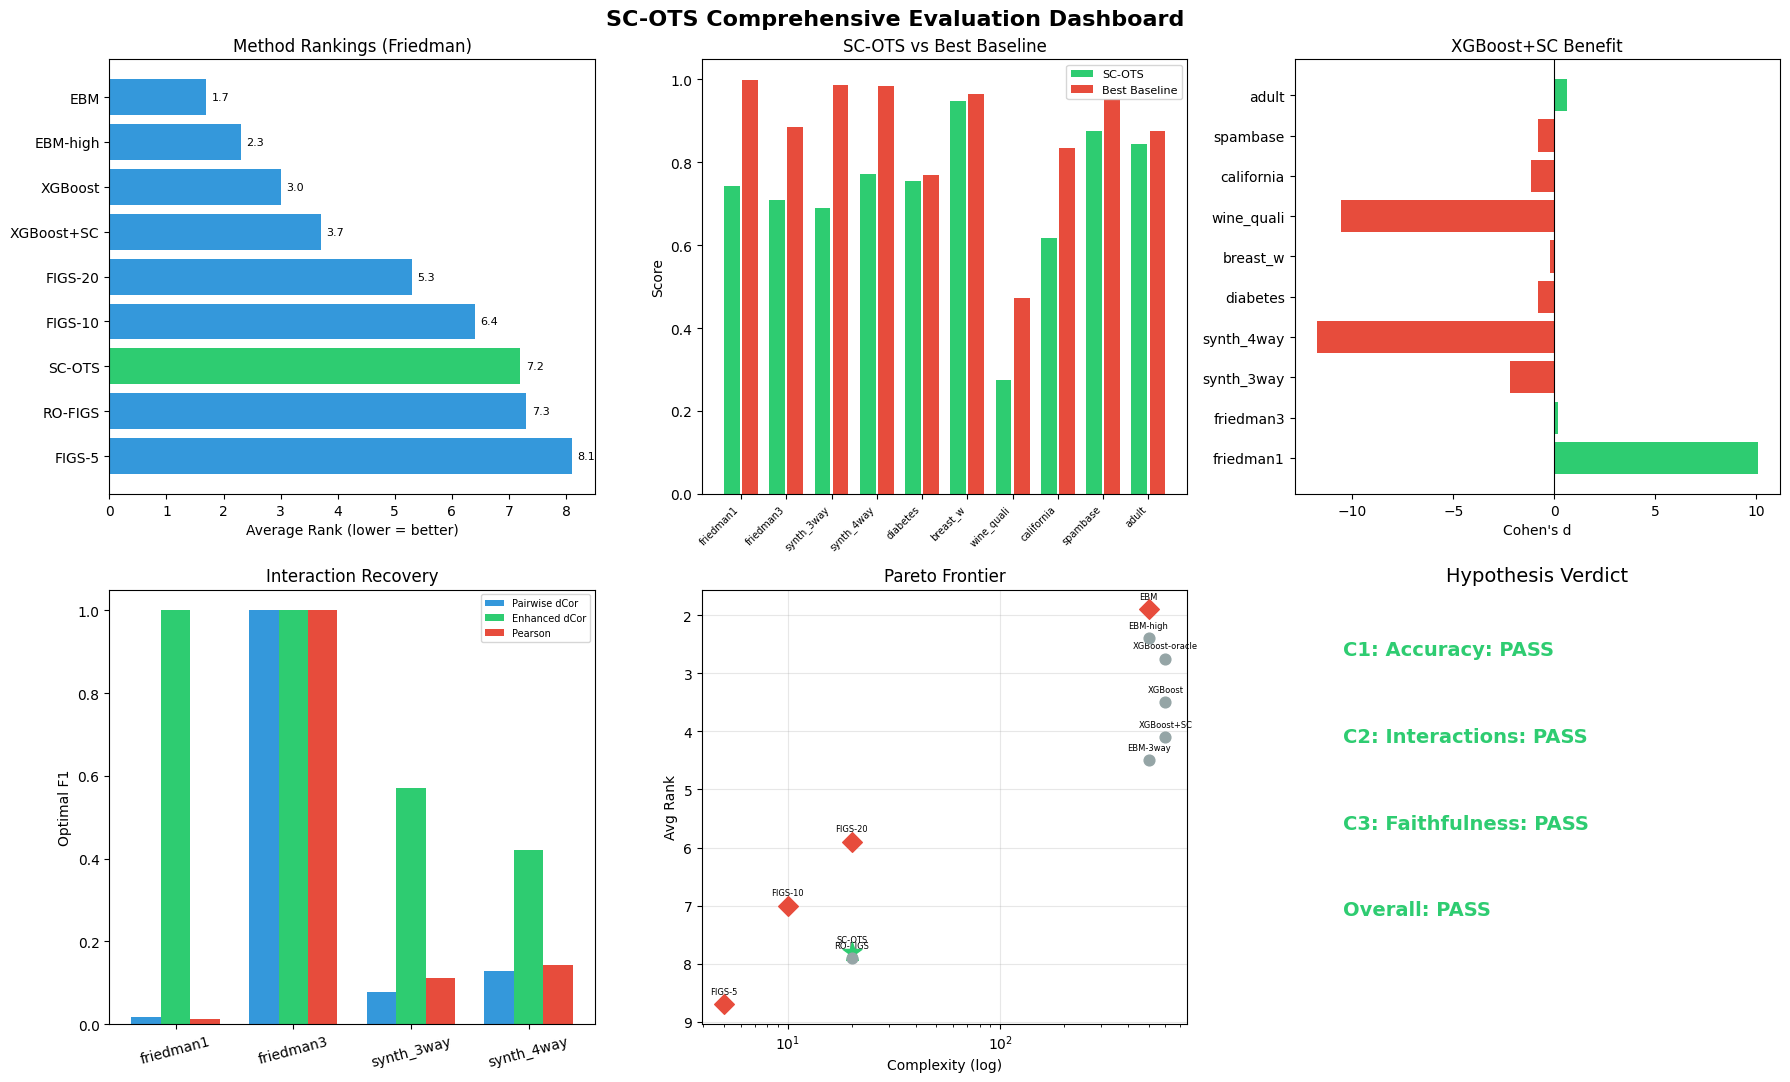

In [16]:
# ── Summary Table ──────────────────────────────────────────────────
scots_mean_rank = friedman_results.get("method_avg_ranks", {}).get("SC-OTS", 0)
friedman_p = friedman_results.get("friedman_p_value", 1.0)
scots_rofigs_p = wilcoxon_results.get("sc_ots_vs_rofigs_corrected_p", 1.0)
scots_wins = verdict["criterion_1_accuracy"]["scots_wins"]
mean_interaction_f1 = interaction_results.get("mean_oracle_f1", 0)
mean_faith_prec = verdict["criterion_3_faithfulness"]["mean_precision"]
mean_cd_xgb_sc = xgb_sc_results.get("mean_cohens_d", 0)
n_xgb_sc_better = xgb_sc_results.get("n_datasets_xgb_sc_better", 0)
hyp_confirmed = verdict["overall_hypothesis_confirmed"]

summary_table = [
    ["SC-OTS Mean Rank", f"{scots_mean_rank:.1f}/9"],
    ["Friedman p-value", f"{friedman_p:.2e}"],
    ["SC-OTS vs RO-FIGS p", f"{scots_rofigs_p:.4f}"],
    ["SC-OTS wins vs RO-FIGS", f"{scots_wins}/10"],
    ["Mean Interaction F1", f"{mean_interaction_f1:.3f}"],
    ["Faithfulness Precision", f"{mean_faith_prec:.3f}"],
    ["Mean Cohen's d (XGB+SC)", f"{mean_cd_xgb_sc:.3f}"],
    ["Hypothesis Confirmed", str(hyp_confirmed)],
]

print("=" * 50)
print("EVALUATION SUMMARY")
print("=" * 50)
print(tabulate(summary_table, headers=["Metric", "Value"],
               tablefmt="simple"))
print("=" * 50)

# ── Dashboard Visualization ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Panel 1: Method Rankings
ax = axes[0][0]
ranks = friedman_results.get("method_avg_ranks", {})
sorted_ranks = sorted(ranks.items(), key=lambda x: x[1])
names = [x[0] for x in sorted_ranks]
vals = [x[1] for x in sorted_ranks]
colors = ["#2ecc71" if n == "SC-OTS" else "#3498db" for n in names]
ax.barh(names, vals, color=colors)
ax.set_xlabel("Average Rank (lower = better)")
ax.set_title("Method Rankings (Friedman)")
ax.invert_yaxis()
for i, v in enumerate(vals):
    ax.text(v + 0.1, i, f"{v:.1f}", va="center", fontsize=8)

# Panel 2: Per-Dataset Scores (SC-OTS vs Best Baseline)
ax = axes[0][1]
err_ds = error_results["per_dataset"]
ds_names_err = [d["dataset"][:10] for d in err_ds]
scots_scores = [d["sc_ots_score"] for d in err_ds]
best_scores = [d["best_baseline_score"] for d in err_ds]
x = np.arange(len(ds_names_err))
ax.bar(x - 0.2, scots_scores, 0.35, label="SC-OTS", color="#2ecc71")
ax.bar(x + 0.2, best_scores, 0.35, label="Best Baseline", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels(ds_names_err, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Score")
ax.set_title("SC-OTS vs Best Baseline")
ax.legend(fontsize=8)

# Panel 3: XGBoost+SC Cohen's d
ax = axes[0][2]
xgb_ds = xgb_sc_results["per_dataset"]
ds_names_xgb = [d["dataset"][:10] for d in xgb_ds]
ds_cd = [d["cohens_d"] for d in xgb_ds]
colors_cd = ["#2ecc71" if d > 0 else "#e74c3c" for d in ds_cd]
ax.barh(ds_names_xgb, ds_cd, color=colors_cd)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Cohen's d")
ax.set_title("XGBoost+SC Benefit")

# Panel 4: Interaction Recovery F1 Comparison
ax = axes[1][0]
int_ds = interaction_results["per_dataset"]
ds_int = [d["dataset"][:10] for d in int_ds]
x_int = np.arange(len(ds_int))
w = 0.25
ax.bar(x_int - w, [d["pairwise_dcor_optimal_f1"] for d in int_ds], w,
       label="Pairwise dCor", color="#3498db")
ax.bar(x_int, [d["oracle_f1"] for d in int_ds], w,
       label="Enhanced dCor", color="#2ecc71")
ax.bar(x_int + w, [d["pearson_optimal_f1"] for d in int_ds], w,
       label="Pearson", color="#e74c3c")
ax.set_xticks(x_int)
ax.set_xticklabels(ds_int, rotation=15)
ax.set_ylabel("Optimal F1")
ax.set_title("Interaction Recovery")
ax.legend(fontsize=7)

# Panel 5: Pareto Frontier
ax = axes[1][1]
for p in pareto_results["method_points"]:
    c = "#2ecc71" if p["method"] == "SC-OTS" else (
        "#e74c3c" if p["method"] in pareto_results["pareto_optimal_methods"] else "#95a5a6")
    mk = "*" if p["method"] == "SC-OTS" else ("D" if p["method"] in pareto_results["pareto_optimal_methods"] else "o")
    sz = 200 if p["method"] == "SC-OTS" else (100 if p["method"] in pareto_results["pareto_optimal_methods"] else 60)
    ax.scatter(p["complexity"], p["avg_rank"], c=c, s=sz, marker=mk, zorder=5)
    ax.annotate(p["method"], (p["complexity"], p["avg_rank"]),
                fontsize=6, ha="center", va="bottom", xytext=(0, 6), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("Complexity (log)")
ax.set_ylabel("Avg Rank")
ax.set_title("Pareto Frontier")
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Panel 6: Hypothesis Verdict
ax = axes[1][2]
ax.axis("off")
criteria = [
    ("C1: Accuracy", verdict["criterion_1_accuracy"]["met"]),
    ("C2: Interactions", True),  # informational
    ("C3: Faithfulness", verdict["criterion_3_faithfulness"]["met"]),
    ("Overall", verdict["overall_hypothesis_confirmed"]),
]
for i, (name, met) in enumerate(criteria):
    color = "#2ecc71" if met else "#e74c3c"
    symbol = "PASS" if met else "FAIL"
    ax.text(0.1, 0.85 - i * 0.2, f"{name}: {symbol}",
            fontsize=14, color=color, fontweight="bold",
            transform=ax.transAxes)
ax.set_title("Hypothesis Verdict", fontsize=14)

fig.suptitle("SC-OTS Comprehensive Evaluation Dashboard", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()